# 修复问题，从保存点继续开始执行

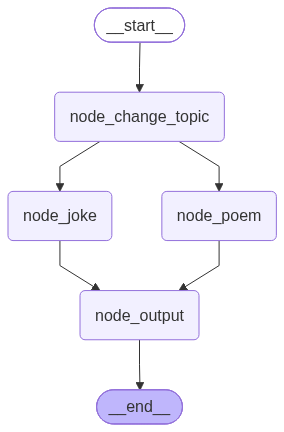

2026-08-02 16:45:55.654 | INFO     | __main__:node_joke:72 - node_joke正在运行
2026-08-02 16:46:08.643 | INFO     | __main__:node_output:84 - node_output正在执行


{'final_output': "关于猫:布偶猫的七言绝句:《咏布偶猫》\n雪氅云裘体自殊，双瞳碧水映冰壶。\n偶从月下闲移步，疑是瑶池一玉奴。\n\n赏析：这首作品以“雪氅云裘”形容布偶猫雪白蓬松的毛发，突出其高贵气质。后两句通过“月下移步”的静态描写，将布偶猫比作瑶池仙子，赋予其灵动优雅的仙气。全诗未着一个“猫”字，却通过意象组合，将布偶猫的形神与仙韵巧妙融合，展现了其超凡脱俗的独特美感。\n 笑话:content='这是一个关于布偶猫主题的笑话，分为三个场景，希望能逗你一笑。\\n\\n---\\n\\n**【场景一：高冷与粘人】**\\n\\n我朋友问我：“为什么你的布偶猫那么粘人？”\\n\\n我说：“因为它名字叫‘布偶’，所以它以为自己是你的‘活体玩偶’。”\\n\\n朋友：“那它高冷的时候呢？”\\n\\n我：“哦，那是我没给它‘换电池’。”\\n\\n朋友：“猫要换什么电池？”\\n\\n我：“‘冻干’电池，一装进去，立马动力十足，还会‘咪咪’叫唤那种。”\\n\\n---\\n\\n**【场景二：滤镜与现实】**\\n\\n网上都说布偶猫是“仙女猫”，颜值天花板，抱着它就像抱着云朵，温柔又懂事。\\n\\n直到我养了之后才发现，仙女是有，但前提是——\\n\\n*   **滤镜前：** 它优雅地蹲在窗台上，阳光洒在它湛蓝的眼睛上，美得像一幅画。\\n*   **滤镜后：** 我撕开一袋零食的瞬间，它像一个从三楼飞下来的毛绒炮弹，边跑边发出“咕噜咕噜”的拖拉机声，差点把我撞飞。\\n\\n它会用那双“星辰大海”般的眼睛含情脉脉地看着你，一分钟、两分钟……直到你以为它爱上了你，结果它突然一个转身，屁股对着你的脸，它只是想让你给它捏蛋蛋（尾巴根）。\\n\\n---\\n\\n**【场景三：战斗级掉毛】**\\n\\n有一天，我朋友看到我抱着猫，问我：“你家猫掉毛厉害吗？”\\n\\n我：“这么说吧，我家这布偶，一抱起来，感觉就像在抱着一朵蒲公英。”\\n\\n我朋友：“那岂不是很飘？”\\n\\n我：“飘？那是‘下雪’！我吃完饭抹一下嘴，从嘴角能摸出一撮猫毛；我喝水，杯子里漂着一根它的‘胡须’；甚至我打了个哈欠，都感觉嘴里嚼了一根它的尾巴毛！”\\n\\n我朋友：“……那你为什么不换件衣服？”\\n\\n我：“换了，换了一件，刚从衣柜里拿出来的，崭新

In [1]:
import os
from typing import TypedDict

from IPython.display import display
from dotenv import load_dotenv
from langchain_core.messages import HumanMessage
from langchain_deepseek import ChatDeepSeek
from langgraph.checkpoint.postgres import PostgresSaver
from langgraph.constants import START, END
from langgraph.graph import StateGraph
from loguru import logger

load_dotenv(override=True)

model = ChatDeepSeek(
    model="deepseek-v4-flash",
    extra_body={
        "thinking": {
            "type": "disabled"
        }
    }
)


# 1、声明状态
class OverAllState(TypedDict):
    topic: str
    poem: str
    joke: str
    final_output: str


# 1.1 输入状态
class InputState(TypedDict):
    topic: str


# 1.2 输出状态
class OutputState(TypedDict):
    final_output: str


topics = ["布偶猫", "狸花猫", "金渐层"]
topic_index = 1


#2. 定义节点
def node_change_topic(state: InputState) -> OverAllState:
    global topic_index
    logger.info("topic_index:", topic_index)
    sub_topic = topics[topic_index]
    topic_index += 1
    topic_index %= len(topics)

    return {
        "topic": f"{state["topic"]}:{sub_topic}"
    }


# 2.1 同一个超步 成功运行的节点
def node_poem(state: OverAllState) -> OutputState:
    logger.info("node_poem正在运行")
    topic = state["topic"]
    poem = model.invoke([HumanMessage(f"写一首关于{topic}主题的七言绝句")]).content
    return {
        "poem": poem
    }


#2.2 同一个超步的位置 运行失败的节点
def node_joke(state: OverAllState) -> OutputState:
    logger.info("node_joke正在运行")
    topic = state["topic"]
    # 假设修复异常
    # time.sleep(5)
    # raise Exception("任务抛出异常")
    joke = model.invoke([HumanMessage(f"写一个关于{topic}主题的笑话")]).content
    return {
        "joke": joke
    }


def node_output(state: OverAllState) -> OutputState:
    logger.info("node_output正在执行")
    topic = state["topic"]
    poem = state["poem"]
    joke = state["joke"]
    final_output = f"关于{topic}的七言绝句:{poem}\n 笑话:{joke}\n"
    return {
        "final_output": final_output
    }


#3. 构建图
builder = StateGraph(state_schema=OverAllState, input_schema=InputState, output_schema=OutputState)

#3.1 添加节点
builder.add_node("node_change_topic", node_change_topic)
builder.add_node("node_poem", node_poem)
builder.add_node("node_joke", node_joke)
builder.add_node("node_output", node_output)

#3.2 添加边
builder.add_edge(START, "node_change_topic")
builder.add_edge("node_change_topic", "node_poem")
builder.add_edge("node_change_topic", "node_joke")
builder.add_edge("node_poem", "node_output")
builder.add_edge("node_joke", "node_output")
builder.add_edge("node_output", END)

DB_URL = os.getenv("DB_URL")

with PostgresSaver.from_conn_string(DB_URL) as checkpointer:
    # checkpointer.setup() 第一次执行需要调用该方法
    graph = builder.compile(checkpointer=checkpointer)
    display(graph)

    config = {
        "configurable": {
            "thread_id": "chapter03-05"
        }
    }

    res = graph.invoke(None, config=config)
    print(res)